<a href="https://colab.research.google.com/github/Sanjaiguru06/ML-Practice-Experiments/blob/main/Experiment_7%20HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

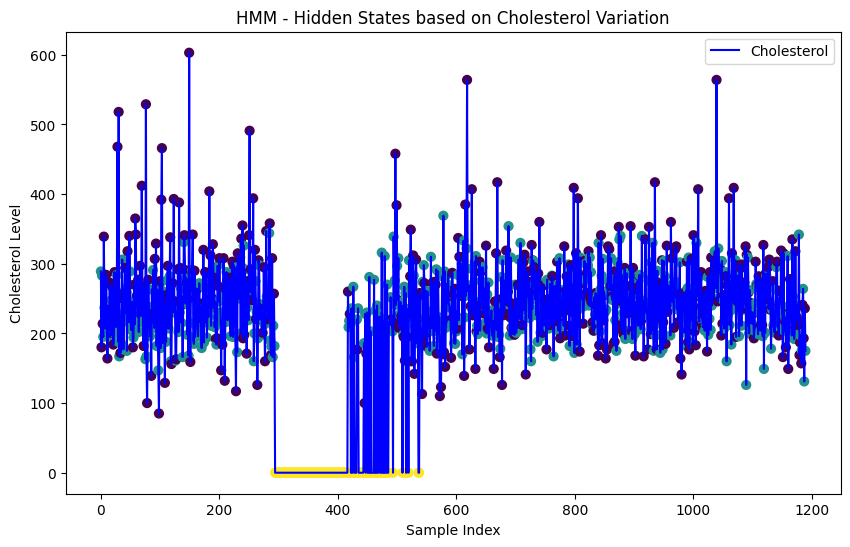

        age  cholesterol  max heart rate   oldpeak
0  0.037685     0.441464        0.043464  0.373005
1 -0.109465     0.280571        0.174522 -0.260166
2  0.269226    -2.075047       -0.695765 -0.089722
HMM completed successfully. Output saved as 'HMM_output.csv'


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/sample_data/dataset.csv")
X = df[["age", "cholesterol", "max heart rate", "oldpeak"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_states = 3
model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", random_state=42)
model.fit(X_scaled)

hidden_states = model.predict(X_scaled)
df["HMM_State"] = hidden_states

plt.figure(figsize=(10,6))
plt.plot(df.index, df["cholesterol"], label="Cholesterol", color="blue")
plt.scatter(df.index, df["cholesterol"], c=hidden_states, cmap="viridis", s=40)
plt.title("HMM - Hidden States based on Cholesterol Variation")
plt.xlabel("Sample Index")
plt.ylabel("Cholesterol Level")
plt.legend()
plt.show()

state_means = pd.DataFrame(model.means_, columns=X.columns)
print(state_means)

df.to_csv("HMM_output.csv", index=False)
print("HMM completed successfully. Output saved as 'HMM_output.csv'")
